In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── MLflow Setup ──
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Assignment3_GAN_StudentA")
print("MLflow experiment set: Assignment3_GAN_StudentA")

Using device: cpu


2026/03/12 01:48:29 INFO mlflow.tracking.fluent: Experiment with name 'Assignment3_GAN_StudentA' does not exist. Creating a new experiment.


MLflow experiment set: Assignment3_GAN_StudentA


In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, img_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)

G = Generator().to(device)


In [3]:
class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

D = Discriminator().to(device)


In [4]:
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

df = pd.read_csv(r'fashion-mnist_train.csv')
X = df.drop('label', axis=1).values.astype('float32')
X = (X / 255.0) * 2 - 1  # normalize to [-1, 1]
X_tensor = torch.tensor(X)
print(f"Dataset loaded — {len(X_tensor)} samples")

Dataset loaded — 60000 samples


In [5]:
# ── Helper functions (re-used for every run) ──

def train_discriminator(G, D, criterion, opt_D, real, real_labels, fake_labels, latent_dim):
    """One discriminator training step."""
    noise = torch.randn(real.size(0), latent_dim, device=device)
    fake = G(noise).detach()
    loss = criterion(D(real), real_labels) + criterion(D(fake), fake_labels)
    opt_D.zero_grad()
    loss.backward()
    opt_D.step()
    return loss.item(), fake


def train_generator(G, D, criterion, opt_G, bs, real_labels, latent_dim):
    """One generator training step."""
    noise = torch.randn(bs, latent_dim, device=device)
    loss = criterion(D(G(noise)), real_labels)
    opt_G.zero_grad()
    loss.backward()
    opt_G.step()
    return loss.item()


@torch.no_grad()
def compute_accuracy(D, real, fake):
    """Discriminator accuracy on real and fake samples."""
    real_correct = (D(real) >= 0.5).sum().item()
    fake_correct = (D(fake) < 0.5).sum().item()
    return real_correct, fake_correct

In [6]:
# ── Experiment Configurations (5 runs with varied hyperparameters) ──
configs = [
    {"lr": 0.0002, "batch_size": 512, "epochs": 5, "latent_dim": 100},
    {"lr": 0.001,  "batch_size": 512, "epochs": 5, "latent_dim": 100},
    {"lr": 0.0001, "batch_size": 512, "epochs": 5, "latent_dim": 100},
    {"lr": 0.0002, "batch_size": 256, "epochs": 5, "latent_dim": 100},
    {"lr": 0.0002, "batch_size": 128, "epochs": 5, "latent_dim": 100},
]

for run_idx, cfg in enumerate(configs, 1):
    LR         = cfg["lr"]
    BATCH_SIZE = cfg["batch_size"]
    EPOCHS     = cfg["epochs"]
    LATENT_DIM = cfg["latent_dim"]

    # Fresh models & optimizers each run
    G = Generator(latent_dim=LATENT_DIM).to(device)
    D = Discriminator().to(device)
    criterion = nn.BCELoss()
    opt_G = torch.optim.Adam(G.parameters(), lr=LR)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR)

    loader = DataLoader(TensorDataset(X_tensor), batch_size=BATCH_SIZE, shuffle=True)

    with mlflow.start_run(run_name=f"run_{run_idx}_lr{LR}_bs{BATCH_SIZE}"):
        # ── Log Parameters ──
        mlflow.log_param("learning_rate", LR)
        mlflow.log_param("batch_size", BATCH_SIZE)
        mlflow.log_param("epochs", EPOCHS)
        mlflow.log_param("latent_dim", LATENT_DIM)
        mlflow.log_param("optimizer", "Adam")

        # ── Log Tags ──
        mlflow.set_tag("student_id", "StudentA")
        mlflow.set_tag("model_type", "Vanilla_GAN")
        mlflow.set_tag("dataset", "Fashion-MNIST")

        print(f"\n{'='*60}")
        print(f"RUN {run_idx}/5 — lr={LR}, batch_size={BATCH_SIZE}")
        print(f"{'='*60}")

        for epoch in range(EPOCHS):
            d_real_correct, d_fake_correct, total = 0, 0, 0

            for (imgs,) in loader:
                real = imgs.to(device)
                bs = real.size(0)
                real_labels = torch.ones(bs, 1, device=device)
                fake_labels = torch.zeros(bs, 1, device=device)

                loss_D, fake = train_discriminator(G, D, criterion, opt_D,
                                                   real, real_labels, fake_labels, LATENT_DIM)
                loss_G = train_generator(G, D, criterion, opt_G,
                                         bs, real_labels, LATENT_DIM)

                rc, fc = compute_accuracy(D, real, fake)
                d_real_correct += rc
                d_fake_correct += fc
                total += bs

            acc_real = d_real_correct / total * 100
            acc_fake = d_fake_correct / total * 100
            acc_overall = (d_real_correct + d_fake_correct) / (2 * total) * 100

            # ── Log Metrics (live, per epoch) ──
            mlflow.log_metric("d_loss", loss_D, step=epoch + 1)
            mlflow.log_metric("g_loss", loss_G, step=epoch + 1)
            mlflow.log_metric("acc_real", acc_real, step=epoch + 1)
            mlflow.log_metric("acc_fake", acc_fake, step=epoch + 1)
            mlflow.log_metric("d_accuracy", acc_overall, step=epoch + 1)

            print(f"  Epoch {epoch+1}/{EPOCHS} | D_loss: {loss_D:.4f} | G_loss: {loss_G:.4f} | "
                  f"D_Acc: {acc_overall:.1f}%")

        # ── Log Final Metrics ──
        mlflow.log_metric("final_d_loss", loss_D)
        mlflow.log_metric("final_g_loss", loss_G)
        mlflow.log_metric("final_d_accuracy", acc_overall)

        # ── Log Model Artifact ──
        mlflow.pytorch.log_model(G, "generator_model")

        print(f"  ✓ Run {run_idx} logged to MLflow")

print("\n✅ All 5 runs completed and logged to MLflow!")


RUN 1/5 — lr=0.0002, batch_size=512
  Epoch 1/5 | D_loss: 0.2501 | G_loss: 2.7196 | D_Acc: 86.3%
  Epoch 2/5 | D_loss: 0.2706 | G_loss: 2.6439 | D_Acc: 99.8%
  Epoch 3/5 | D_loss: 0.2959 | G_loss: 5.8192 | D_Acc: 97.6%
  Epoch 4/5 | D_loss: 0.0279 | G_loss: 5.2306 | D_Acc: 99.5%


2026/03/12 01:49:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Epoch 5/5 | D_loss: 0.1238 | G_loss: 3.6953 | D_Acc: 99.5%


2026/03/12 01:49:37 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  ✓ Run 1 logged to MLflow
🏃 View run run_1_lr0.0002_bs512 at: http://localhost:5000/#/experiments/1/runs/334093f2f28345588edf478540b507b4
🧪 View experiment at: http://localhost:5000/#/experiments/1

RUN 2/5 — lr=0.001, batch_size=512
  Epoch 1/5 | D_loss: 0.0128 | G_loss: 9.0014 | D_Acc: 94.8%
  Epoch 2/5 | D_loss: 0.0116 | G_loss: 67.8174 | D_Acc: 96.8%
  Epoch 3/5 | D_loss: 0.3317 | G_loss: 6.0639 | D_Acc: 94.0%
  Epoch 4/5 | D_loss: 0.0363 | G_loss: 8.4150 | D_Acc: 97.1%


...

  ✓ Run 4 logged to MLflow
🏃 View run run_4_lr0.0002_bs256 at: http://localhost:5000/#/experiments/1/runs/613a8dc91019403c8d8684bbfb6a1367
🧪 View experiment at: http://localhost:5000/#/experiments/1

RUN 5/5 — lr=0.0002, batch_size=128
  Epoch 1/5 | D_loss: 0.0624 | G_loss: 5.8845 | D_Acc: 95.5%
  Epoch 2/5 | D_loss: 0.0459 | G_loss: 5.4488 | D_Acc: 99.4%
  Epoch 3/5 | D_loss: 0.0509 | G_loss: 7.9503 | D_Acc: 99.6%
  Epoch 4/5 | D_loss: 0.0637 | G_loss: 9.5854 | D_Acc: 99.4%


2026/03/12 01:53:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Epoch 5/5 | D_loss: 0.0989 | G_loss: 6.9427 | D_Acc: 98.9%


2026/03/12 01:53:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  ✓ Run 5 logged to MLflow
🏃 View run run_5_lr0.0002_bs128 at: http://localhost:5000/#/experiments/1/runs/00336d673e2340fb892604e293845930
🧪 View experiment at: http://localhost:5000/#/experiments/1

✅ All 5 runs completed and logged to MLflow!


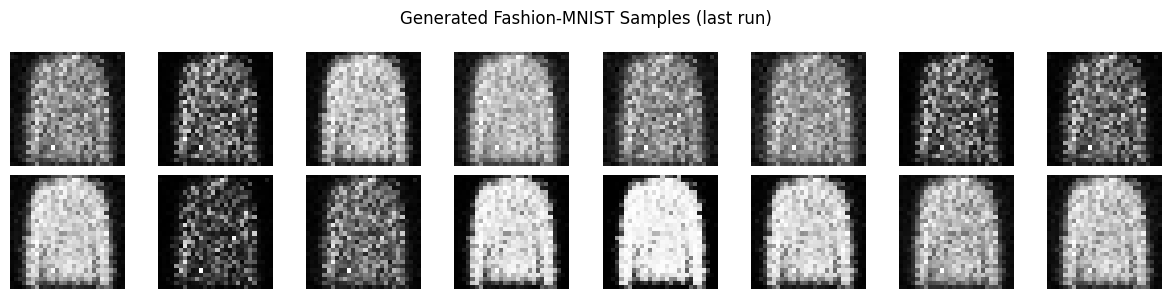

Saved generated_samples.png


In [7]:
# ── Generate sample images from the last trained Generator ──
@torch.no_grad()
def generate_samples(G, latent_dim=100, n=16, nrow=8):
    """Generate and display a grid of fake images."""
    G.eval()
    noise = torch.randn(n, latent_dim, device=device)
    samples = G(noise).cpu().view(n, 28, 28)
    G.train()

    ncol = n // nrow
    fig, axes = plt.subplots(ncol, nrow, figsize=(12, 3))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i], cmap='gray')
        ax.axis('off')
    plt.suptitle("Generated Fashion-MNIST Samples (last run)")
    plt.tight_layout()
    plt.savefig("generated_samples.png", dpi=100)
    plt.show()
    print("Saved generated_samples.png")

generate_samples(G)